# Understanding procedural variation (AF ablation)

This notebook explains **what we measured**, **how we analyzed it**, and **how the transcript layer fits in**—using the same definitions as `scripts/doctor_abl_variation_analysis.py`.

**Sections**
1. **Macro timing data** — case workbook, standard cases, phase durations
2. **Case-time ANCOVA** — physician, `#ABL`, ABL TIME, and **extended specs** (applications/Abl; pre-ablation phase minutes)
3. **Same-doctor, same-`#ABL` cells** — where residual variation shows up by phase
4. **Transcript coding** — micro-steps and categories mapped to macro phases (illustrative, not case-matched)

**Dependencies:** from the repo root, `pip install -r requirements.txt` (includes `openpyxl` for the Excel workbook).

Run all cells from the **repository root** (recommended), or open Jupyter with `cwd` set to the repo so `scripts/` imports resolve (see setup cell).

## 0. Setup: project root and imports

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root (works if cwd is repo root or notebooks/)
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.data_utils import DATA_PATH, load_case_data
from scripts.doctor_abl_variation_analysis_anova import (
    ACCESS,
    ABL_COUNT,
    ABL_DURATION,
    ABL_TIME,
    CASE_TIME,
    POST_CARE,
    PRE_MAP,
    PT_PREP,
    SKIN_SKIN,
    TSP,
    build_case_time_ancova,
    build_case_time_ancova_extended,
    build_case_time_ancova_preamp_controls,
    build_doctor_abl_cell_summary,
    build_within_cell_variation_summary,
)

OUTPUT_DIR = ROOT / "outputs"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True})
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass
print("ROOT:", ROOT)
print("Data:", DATA_PATH.exists(), DATA_PATH)

ROOT: /Users/ellakennedy/433-Module4/MSE433-Module4-1
Data: True /Users/ellakennedy/433-Module4/MSE433-Module4-1/data/MSE433_M4_Data.xlsx


## 1. What the dataset contains

We load the EP lab workbook and **exclude “complex” cases** (rows with a non-empty `Note`), matching the analysis scripts.

**Macro phases** (minutes unless noted) are columns such as:
- **CASE TIME** — cath in to cath out (overall lab footprint for the procedure segment)
- **SKIN-SKIN** — access to cath out
- **PT PREP / INTUBATION**, **ACCESS**, **TSP**, **PRE-MAP**, **ABL DURATION**, **ABL TIME** (pulse-on), **POST CARE**

The schematic below is **not to scale**; it only shows **order** of phases.

In [3]:
all_cases = load_case_data(DATA_PATH)
standard_cases = all_cases.loc[~all_cases["complex_case"]].copy()
print(f"All rows: {len(all_cases)} | Standard (analysis) cases: {len(standard_cases)}")
# Use real Excel column names (ABL_COUNT in code = "#ABL")
standard_cases[
    ["CASE #", "PHYSICIAN", ABL_COUNT, CASE_TIME, ABL_TIME, ABL_DURATION]
].head()

All rows: 150 | Standard (analysis) cases: 126


,CASE #,PHYSICIAN,#ABL,CASE TIME (Cath In-Out),ABL TIME (Min),ABL DURATION (Abl Start-End)
4,1,Dr. A,21.0,50.0,7.35,28.0
5,2,Dr. A,19.0,47.0,6.65,25.0
6,3,Dr. A,24.0,37.0,8.40,41.0
7,4,Dr. B,21.0,91.0,7.35,41.0
8,5,Dr. B,22.0,49.0,7.70,33.0


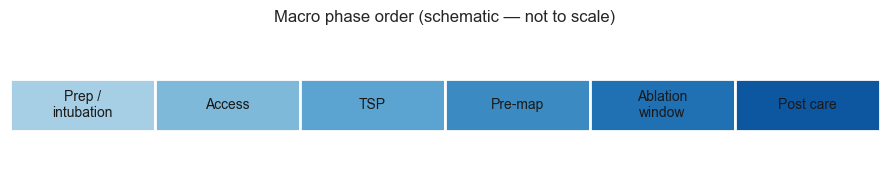

In [4]:
# Visual: ordered macro phases (equal width for clarity — not proportional to duration)
phase_order = [
    "Prep /\nintubation",
    "Access",
    "TSP",
    "Pre-map",
    "Ablation\nwindow",
    "Post care",
]
n = len(phase_order)
fig, ax = plt.subplots(figsize=(9, 2))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, n))
left = 0.0
for i, (label, c) in enumerate(zip(phase_order, colors)):
    ax.barh(0, 1, left=left, height=0.35, color=c, edgecolor="white", linewidth=2)
    ax.text(left + 0.5, 0, label, ha="center", va="center", fontsize=10, color="0.1")
    left += 1
ax.set_xlim(0, n)
ax.set_ylim(-0.5, 0.5)
ax.axis("off")
ax.set_title("Macro phase order (schematic — not to scale)")
plt.tight_layout()
plt.show()

## 2. Case-time ANCOVA — what explains **overall case time**?

We regress **CASE TIME** on:
- **Physician** (categorical)
- **`#ABL`** (lesion count, continuous)
- **ABL TIME (Min)** (pulse-on time, continuous)

We report **Type II ANOVA** and **partial η²** here as `eta_sq_total` = effect sum of squares / **total** sum of squares (same convention as `outputs/case_time_ancova.csv`).

**Interpretation:** If physician stays significant after controlling for workload proxies, **provider-level differences** remain important beyond “how many lesions” and “how long energy was on.”

**More predictors (next cell):** The script also fits **extended** models saved as `outputs/case_time_ancova_extended.csv` (+ `#APPLICATIONS 3/Abl`) and `outputs/case_time_ancova_preamp_controls.csv` (+ prep, access, TSP, pre-map). Phase minutes overlap the same timeline as case time, so treat extra terms as **shared-variance controls**, not as independent "causes."

,effect,n,r_squared,sum_sq,df,F,p_value,eta_sq_total
0,C(PHYSICIAN),122,0.2658,2185.8069,2.0,8.6312,0.000319,0.1249
1,"Q(""#ABL"")",122,0.2658,354.3231,1.0,2.7983,0.097038,0.0203
2,"Q(""ABL TIME (Min)"")",122,0.2658,139.4731,1.0,1.1015,0.296102,0.0080


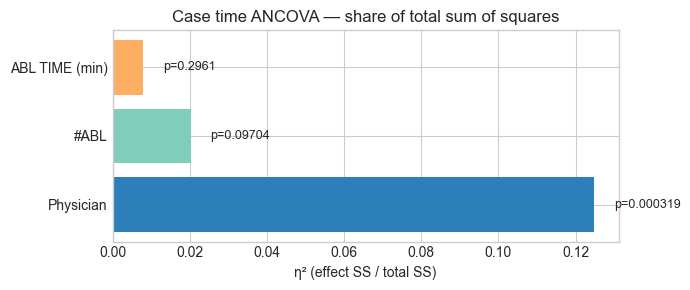

In [5]:
def _effect_label(effect: str) -> str:
    if effect.startswith("C(PHYSICIAN)"):
        return "Physician"
    if "#ABL" in effect:
        return "#ABL"
    if "ABL TIME" in effect:
        return "ABL TIME (min)"
    return effect


ancova = build_case_time_ancova(standard_cases)
try:
    from IPython.display import display

    display(ancova)
except ImportError:
    print(ancova.to_string())

plot_df = ancova.assign(label=ancova["effect"].map(_effect_label), eta=ancova["eta_sq_total"])
fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#2c7fb8", "#7fcdbb", "#fdae61"]
ax.barh(plot_df["label"], plot_df["eta"], color=colors)
ax.set_xlabel("η² (effect SS / total SS)")
ax.set_title("Case time ANCOVA — share of total sum of squares")
for _, row in plot_df.iterrows():
    ax.text(float(row["eta"]) + 0.005, row["label"], f"p={row['p_value']:.4g}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2b. Extended predictors (same outcome)

Two **Type II** specifications (also written when you run `python scripts/doctor_abl_variation_analysis.py`):
- **Extended:** physician, `#ABL`, ABL TIME, **`#APPLICATIONS 3/Abl`**.
- **Pre-ablation controls:** physician, **`PT PREP`**, **ACCESS**, **TSP**, **PRE-MAP**, `#ABL`, ABL TIME.

Because several predictors are **parts of the same clock** as case time, use these tables to see **which terms co-move** with case time and whether **physician** still accounts for distinct variance—not to claim independent causal effects.

Extended (+ applications/Abl) | n = 122


,effect,n,r_squared,sum_sq,df,F,p_value,eta_sq_total
0,C(PHYSICIAN),122,0.266,2154.7860,2.0,8.4391,0.000379,0.1259
1,"Q(""#ABL"")",122,0.266,23.6584,1.0,0.1853,0.667645,0.0014
2,"Q(""ABL TIME (Min)"")",122,0.266,122.4074,1.0,0.9588,0.329527,0.0072
3,"Q(""#APPLICATIONS 3/Abl"")",122,0.266,5.3719,1.0,0.0421,0.837832,0.0003


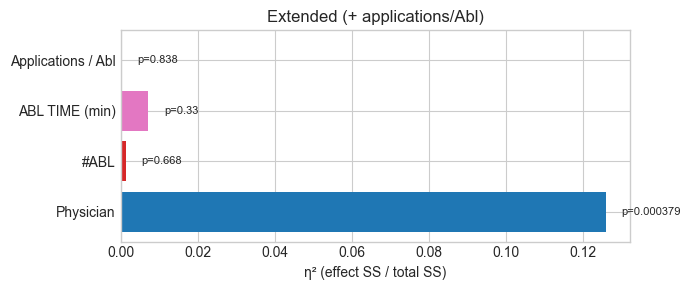

Pre-ablation phase controls | n = 122


,effect,n,r_squared,sum_sq,df,F,p_value,eta_sq_total
0,C(PHYSICIAN),122,0.6831,501.2134,2.0,4.4286,0.014071,0.0402
1,"Q(""PT PREP/INTUBATION Pt-In-Access"")",122,0.6831,660.6663,1.0,11.6751,0.000881,0.0529
2,"Q(""ACCESSS (Min)"")",122,0.6831,319.0851,1.0,5.6388,0.019253,0.0256
3,"Q(""TSP (Min)"")",122,0.6831,2929.1277,1.0,51.7627,0.000000,0.2347
4,"Q(""PRE-MAP (Min)"")",122,0.6831,1124.4300,1.0,19.8706,0.000020,0.0901
5,"Q(""#ABL"")",122,0.6831,463.5168,1.0,8.1911,0.005017,0.0371
6,"Q(""ABL TIME (Min)"")",122,0.6831,87.8883,1.0,1.5531,0.215251,0.0070


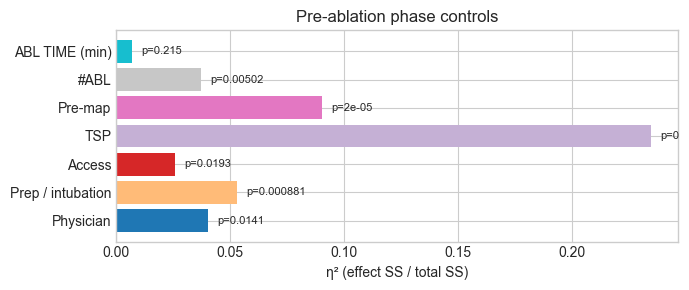

In [6]:
def _effect_label_ext(effect: str) -> str:
    if effect.startswith("C(PHYSICIAN)"):
        return "Physician"
    if "#ABL" in effect and "APPLICATIONS" not in effect:
        return "#ABL"
    if "ABL TIME" in effect:
        return "ABL TIME (min)"
    if "APPLICATIONS" in effect:
        return "Applications / Abl"
    if "PT PREP" in effect:
        return "Prep / intubation"
    if "ACCESSS" in effect:
        return "Access"
    if "TSP" in effect and "PT PREP" not in effect:
        return "TSP"
    if "PRE-MAP" in effect:
        return "Pre-map"
    return effect


ancova_ext = build_case_time_ancova_extended(standard_cases)
ancova_preamp = build_case_time_ancova_preamp_controls(standard_cases)

for title, df in [
    ("Extended (+ applications/Abl)", ancova_ext),
    ("Pre-ablation phase controls", ancova_preamp),
]:
    try:
        from IPython.display import display

        print(title, "| n =", int(df["n"].iloc[0]))
        display(df)
    except ImportError:
        print(title, df.to_string())
    plot_df = df.assign(label=df["effect"].map(_effect_label_ext), eta=df["eta_sq_total"])
    fig_h = max(3.0, 0.42 * len(plot_df))
    fig, ax = plt.subplots(figsize=(7, fig_h))
    colors = plt.cm.tab20(np.linspace(0, 0.92, len(plot_df)))
    ax.barh(plot_df["label"], plot_df["eta"], color=colors)
    ax.set_xlabel("η² (effect SS / total SS)")
    ax.set_title(title)
    for _, row in plot_df.iterrows():
        ax.text(float(row["eta"]) + 0.004, row["label"], f"p={row['p_value']:.3g}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


## 3. Residual variation: **same doctor, same `#ABL`**

To see **where** time still moves after holding **physician** and **lesion count** roughly fixed:

1. Group cases by `(PHYSICIAN, #ABL)` with **at least 2 cases** per cell.
2. For each cell, compute the **sample SD** of each phase duration across cases in that cell.
3. **Average those SDs** across cells → **`mean_within_cell_sd`** (see `outputs/within_cell_phase_variation.csv`).

**Interpretation:** High **mean within-cell SD** means “even when we match doctor and lesion count, this phase duration still bounces around.” **Low** SD means that phase is **stable** under that grouping.

**Key comparison:** **ABL DURATION** (full ablation segment) vs **ABL TIME** (pulse-on only). If **ABL TIME** is nearly flat but **ABL DURATION** is not, the flexible minutes are mostly **non–pulse-on work** inside the ablation window (mapping, repositioning, verification, pauses, etc.).

,phase,mean_within_cell_sd,median_within_cell_sd,mean_within_cell_range,median_within_cell_range
0,CASE TIME (Cath In-Out),10.11,7.77,23.55,21.0
1,SKIN-SKIN (Access to Cath-Out),9.96,8.33,22.95,21.5
2,PT PREP/INTUBATION Pt-In-Access,4.19,3.71,10.10,10.5
3,ABL DURATION (Abl Start-End),4.14,4.24,10.30,11.0
4,TSP (Min),2.99,2.04,7.45,4.0
5,POST CARE/EXTUBATION (Cath-Out to Pt-Out),2.95,2.67,6.75,6.5
6,ACCESSS (Min),1.71,1.12,4.05,2.5
7,PRE-MAP (Min),0.60,0.58,1.35,1.0
8,ABL TIME (Min),0.13,0.00,0.27,0.0


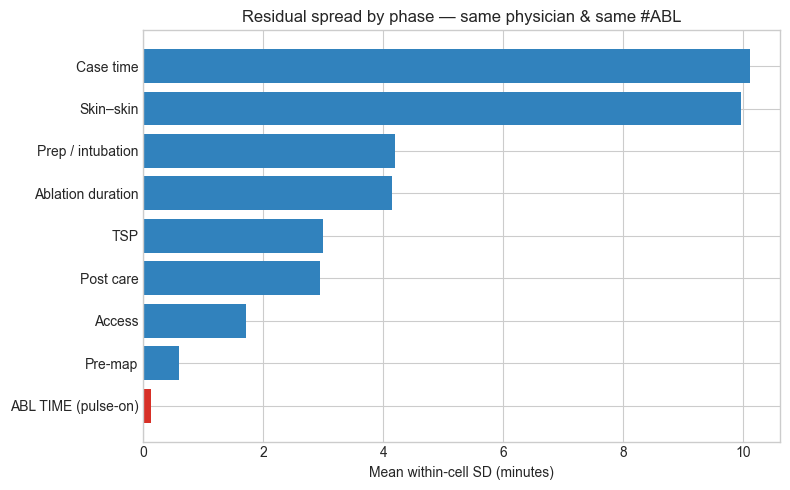

In [7]:
cell_summary = build_doctor_abl_cell_summary(standard_cases, min_cell_size=2)
within_cell = build_within_cell_variation_summary(cell_summary)
try:
    from IPython.display import display

    display(within_cell)
except ImportError:
    print(within_cell.to_string())

# Short labels for plotting
short = {
    CASE_TIME: "Case time",
    SKIN_SKIN: "Skin–skin",
    PT_PREP: "Prep / intubation",
    ACCESS: "Access",
    TSP: "TSP",
    PRE_MAP: "Pre-map",
    ABL_DURATION: "Ablation duration",
    ABL_TIME: "ABL TIME (pulse-on)",
    POST_CARE: "Post care",
}
plot_w = within_cell.copy()
plot_w["short"] = plot_w["phase"].map(short).fillna(plot_w["phase"])
plot_w = plot_w.sort_values("mean_within_cell_sd", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d73027" if "ABL TIME" in p else "#3182bd" for p in plot_w["phase"]]
ax.barh(plot_w["short"], plot_w["mean_within_cell_sd"], color=colors)
ax.set_xlabel("Mean within-cell SD (minutes)")
ax.set_title("Residual spread by phase — same physician & same #ABL")
ax.axvline(0, color="0.5", lw=0.5)
plt.tight_layout()
plt.show()

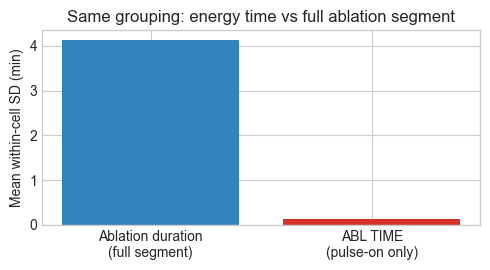

In [8]:
# Focused comparison: ablation window vs pulse-on time (fixed order)
pair = within_cell.set_index("phase").loc[[ABL_DURATION, ABL_TIME]]["mean_within_cell_sd"]
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.bar(
    ["Ablation duration\n(full segment)", "ABL TIME\n(pulse-on only)"],
    [pair.loc[ABL_DURATION], pair.loc[ABL_TIME]],
    color=["#3182bd", "#d73027"],
)
ax.set_ylabel("Mean within-cell SD (min)")
ax.set_title("Same grouping: energy time vs full ablation segment")
plt.tight_layout()
plt.show()

## 4. **Case time** spread by physician

This is **not** the same as the within-cell analysis; it shows **between-physician** spread in overall case time for standard cases (descriptive).

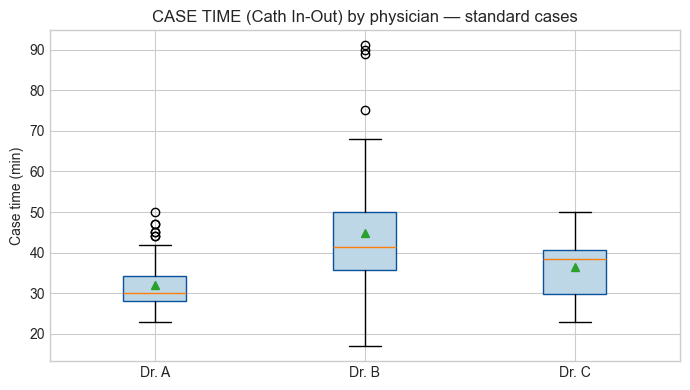

In [9]:
ct = standard_cases.dropna(subset=[CASE_TIME, "PHYSICIAN"])
phys_order = sorted(ct["PHYSICIAN"].astype(str).unique())
fig, ax = plt.subplots(figsize=(7, 4))
box_kw = dict(showmeans=True, patch_artist=True)
try:
    bp = ax.boxplot(
        [ct.loc[ct["PHYSICIAN"] == p, CASE_TIME] for p in phys_order],
        tick_labels=phys_order,
        **box_kw,
    )
except TypeError:
    bp = ax.boxplot(
        [ct.loc[ct["PHYSICIAN"] == p, CASE_TIME] for p in phys_order],
        labels=phys_order,
        **box_kw,
    )
for patch in bp["boxes"]:
    patch.set(facecolor="#bdd7e7", edgecolor="#08519c")
ax.set_ylabel("Case time (min)")
ax.set_title("CASE TIME (Cath In-Out) by physician — standard cases")
plt.tight_layout()
plt.show()